# Heart Disease Classification

A binary classification project on the UCI Cleveland Heart Disease dataset:
predict whether a patient has heart disease from clinical measurements.

**Pipeline:** load → explore → clean/preprocess → train/test split → baseline
model → compare models → evaluate → interpret feature importance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_theme(style="whitegrid")


## 1. Load the data

Source: [UCI Machine Learning Repository — Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease)
(Cleveland subset, 303 patients, 14 attributes).

The raw `num` column is the original severity label (0 = no disease,
1-4 = increasing severity). This project treats it as **binary**:
0 = no disease, 1 = disease present (any severity).


In [2]:
df = pd.read_csv("data/heart.csv")
df["target"] = (df["num"] > 0).astype(int)
df = df.drop(columns=["num"])
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 2. Explore the data

Check shape, types, missing values, and class balance before doing anything else.


In [3]:
print(df.shape)
df.info()


(303, 14)
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [4]:
df.isna().sum()


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

`ca` and `thal` have a handful of missing values (a known quirk of this
dataset — they were originally recorded as `?`). That's a small fraction of
303 rows, so the simplest honest fix is to drop those rows rather than
impute values for a clinical measurement we don't actually have.


In [5]:
before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with missing values, {len(df)} remain.")


Dropped 6 rows with missing values, 297 remain.


In [6]:
df["target"].value_counts(normalize=True).rename("proportion")


target
0    0.538721
1    0.461279
Name: proportion, dtype: float64

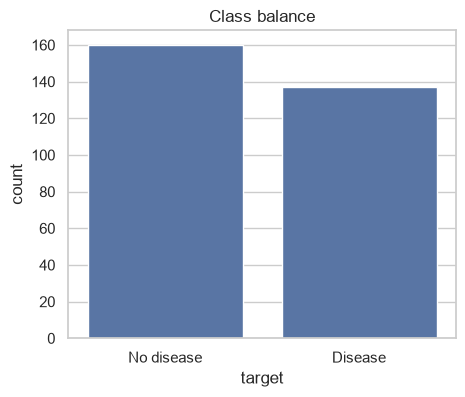

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="target", ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No disease", "Disease"])
ax.set_title("Class balance")
plt.show()


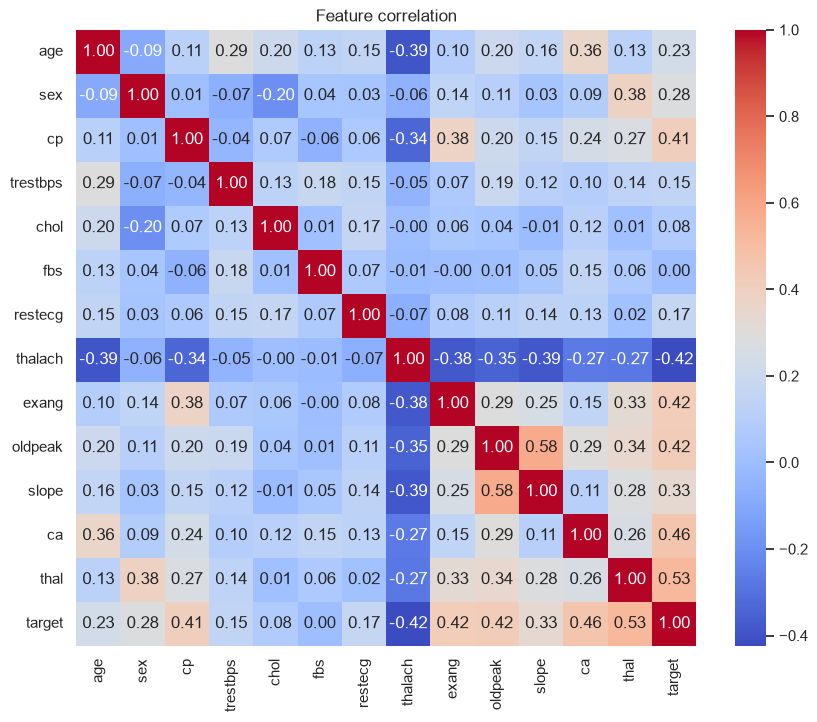

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Feature correlation")
plt.show()


## 3. Preprocess

This dataset (as pulled from UCI) has no missing values and every column is
already numeric, so preprocessing here is light: split features/target,
train/test split (stratified — class balance matters), and scale numeric
features for the distance-based models (logistic regression, KNN).

Tree-based models (decision tree, random forest) don't need scaling, but
scaling doesn't hurt them either, so one scaled feature set is used for all
models to keep the comparison simple.


In [9]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")


Train: 237 rows, Test: 60 rows


## 4. Baseline model — Logistic Regression

Simple, interpretable, and a fair bar for the other models to beat.


In [10]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr, target_names=["No disease", "Disease"]))


              precision    recall  f1-score   support

  No disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



## 5. Compare models

Decision Tree, KNN, and Random Forest against the same train/test split.


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("model").sort_values("roc_auc", ascending=False)
results_df.round(3)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
Logistic Regression,0.833,0.846,0.786,0.815,0.950
KNN,0.883,0.920,0.821,0.868,0.949
Random Forest,0.867,0.885,0.821,0.852,0.949
Decision Tree,0.683,0.680,0.607,0.642,0.679


**Why look past accuracy:** in a medical screening context, a false
negative (telling a sick patient they're healthy) is worse than a false
positive. Recall on the "Disease" class and ROC-AUC matter more here than
raw accuracy — a model can have high accuracy while still missing a
concerning share of real cases if the classes are imbalanced.


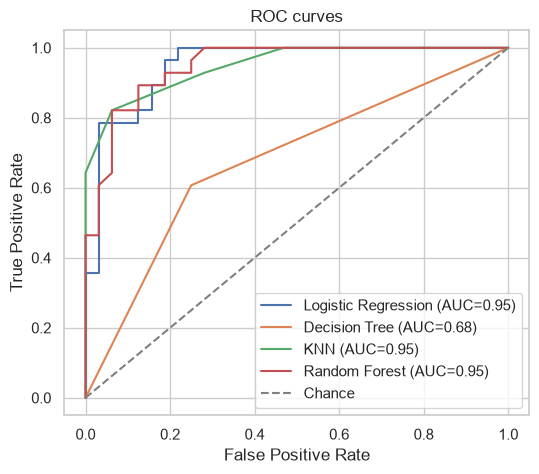

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.2f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves")
ax.legend()
plt.show()


## 6. Confusion matrix — best model

Pick the model with the strongest ROC-AUC from the comparison above and look
at exactly where it goes wrong.


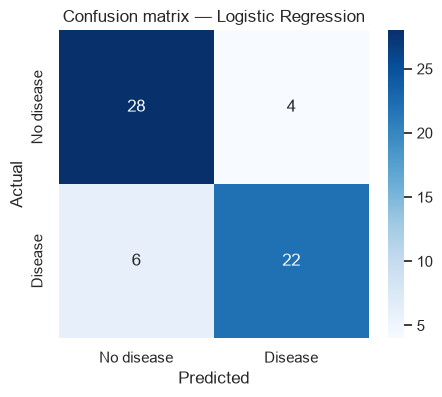

Best model: Logistic Regression
              precision    recall  f1-score   support

  No disease       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



In [13]:
best_name = results_df.index[0]
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No disease", "Disease"],
            yticklabels=["No disease", "Disease"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_name}")
plt.show()

print(f"Best model: {best_name}")
print(classification_report(y_test, y_pred_best, target_names=["No disease", "Disease"]))


## 7. Feature importance

Which measurements actually drive the prediction — ties the model back to
something clinically interpretable, not just a black box that scores well.


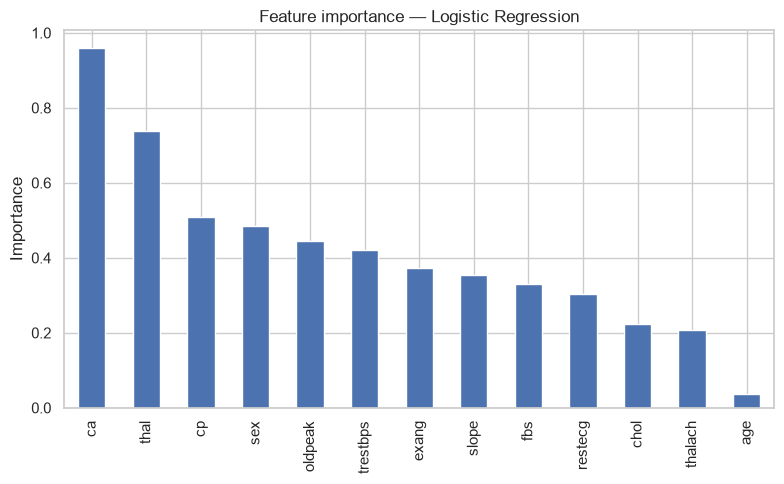

In [14]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    importances.plot(kind="bar", ax=ax)
    ax.set_title(f"Feature importance — {best_name}")
    ax.set_ylabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} doesn't expose a direct importance/coefficient attribute.")


## Conclusion

Fill in after running: which model won, what the top features were, and
whether that matches clinical intuition (e.g. chest pain type, max heart
rate, and ST depression are classic strong predictors in this dataset).

**Possible next steps:** k-fold cross-validation instead of a single split,
hyperparameter tuning (`GridSearchCV`), or testing the model's precision/
recall trade-off at different classification thresholds rather than the
default 0.5.
